##Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

##Load Dataset

In [16]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Salary_dataset.csv')
df.head()

Saving Salary_dataset.csv to Salary_dataset (1).csv


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


##Data Overview

In [17]:
print(df.shape)
df.info()
df.describe()

(30, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


##Data Visualization (Exploration)

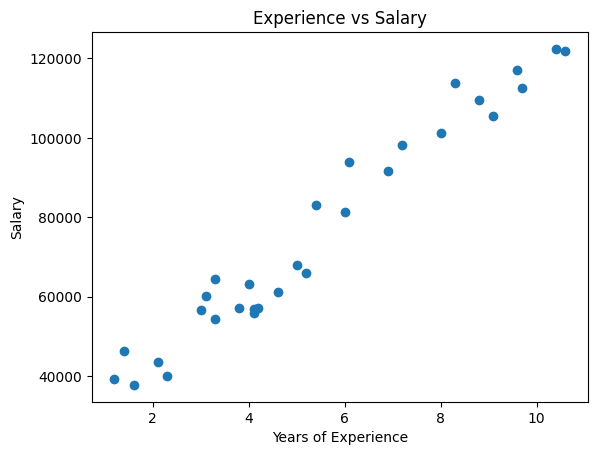

In [18]:
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

##Define Features

In [19]:
X = df[['YearsExperience']]   # single feature
y = df['Salary']

##Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Train Single Feature Model

In [21]:
model_single = LinearRegression()
model_single.fit(X_train, y_train)

LinearRegression()

##Predictions (Single Feature)

In [22]:
y_pred_single = model_single.predict(X_test)

##Evaluate Single Feature Model

In [23]:
rmse_single = np.sqrt(mean_squared_error(y_test, y_pred_single))
r2_single = r2_score(y_test, y_pred_single)

print("Single Feature Model")
print("RMSE:", rmse_single)
print("R2:", r2_single)

Single Feature Model
RMSE: 7059.04362190151
R2: 0.9024461774180497


##Add More Features (Simulated Multiple Regression)

In [24]:
# Example: adding a synthetic feature (for demonstration)
df['TestScore'] = df['Salary'] / 1000  # dummy feature

X_multi = df[['YearsExperience', 'TestScore']]
y_multi = df['Salary']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

##Train Multiple Linear Regression Model

In [25]:
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

LinearRegression()

##Predictions (Multiple Features)

In [26]:
y_pred_multi = model_multi.predict(X_test_m)

##Evaluate Multiple Feature Model

In [27]:
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))
r2_multi = r2_score(y_test_m, y_pred_multi)

print("Multiple Feature Model")
print("RMSE:", rmse_multi)
print("R2:", r2_multi)

Multiple Feature Model
RMSE: 5.940794514955822e-12
R2: 1.0


##Compare Models

In [28]:
print("Comparison:\n")

print("Single Feature -> RMSE:", rmse_single, "R2:", r2_single)
print("Multiple Feature -> RMSE:", rmse_multi, "R2:", r2_multi)

if r2_multi > r2_single:
    print("\nBest Model: Multiple Feature Model")
else:
    print("\nBest Model: Single Feature Model")

Comparison:

Single Feature -> RMSE: 7059.04362190151 R2: 0.9024461774180497
Multiple Feature -> RMSE: 5.940794514955822e-12 R2: 1.0

Best Model: Multiple Feature Model


##Save Best Model

In [29]:
import joblib

best_model = model_multi if r2_multi > r2_single else model_single
joblib.dump(best_model, 'salary_model.pkl')

print("Best model saved successfully!")

Best model saved successfully!


##Example Prediction

In [30]:
# Example input
example = np.array([[5]])  # 5 years experience

pred = model_single.predict(example)
print("Predicted Salary:", pred[0])

Predicted Salary: 71499.2780946286


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
